## Set up

### Import Library

In [2]:
from pathlib import Path
import torch
import pandas as pd
import sys
import os

# go up two levels: Jupyter_notebook → scripts → project_root
project_root = os.path.abspath(os.path.join(os.getcwd(), "../../"))
sys.path.append(project_root)


# reuse functions from your script
# from Archeived.main_predict import get_model, get_dataset, run_pred
from mst.inference.predictor import load_model, get_dataset_class, predict_batch


import warnings
warnings.simplefilter("ignore", UserWarning)

### Set Device - Path - Model

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

run_dir = Path("/home/jovyan/work/MST/runs")

## For DINOv2
# run_folder = Path("DINOv2ViTS/DinoV2ClassifierSlice_Final")
# path_run = run_dir / run_folder

##For New Model
run_folder = Path("DINOv3ViTB")
checkpoint_name = "challenge_mstv3-vit_sch_CB_sub2_best.chkpt"
path_run = run_dir / run_folder / checkpoint_name

Load Model

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = load_model("DinoV2ClassifierSlice", path_run, device)
model.to(device)
model.eval()

Using cache found in /home/jovyan/.cache/torch/hub/facebookresearch_dinov3_main


DinoV2ClassifierSlice(
  (loss_func): CrossEntropyLoss()
  (auc_roc): ModuleDict(
    (train_): MulticlassAUROC()
    (val_): MulticlassAUROC()
    (test_): MulticlassAUROC()
  )
  (acc): ModuleDict(
    (train_): MulticlassAccuracy()
    (val_): MulticlassAccuracy()
    (test_): MulticlassAccuracy()
  )
  (encoder): DinoVisionTransformer(
    (patch_embed): PatchEmbed(
      (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      (norm): Identity()
    )
    (rope_embed): RopePositionEmbedding()
    (blocks): ModuleList(
      (0-11): 12 x SelfAttentionBlock(
        (norm1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): SelfAttention(
          (qkv): LinearKMaskedBias(in_features=768, out_features=2304, bias=True)
          (attn_drop): Dropout(p=0.0, inplace=False)
          (proj): Linear(in_features=768, out_features=768, bias=True)
          (proj_drop): Dropout(p=0.0, inplace=False)
        )
        (ls1): LayerScale()
        (norm2): Layer

### Load Test set

In [4]:
from mst.data.datasets.dataset_3d_odelia import ODELIA_Dataset3D

odelia_root = Path(project_root) / "mst" / "data" / "datasets" / "ODELIA_datasets"
ds_test = ODELIA_Dataset3D(path_root=odelia_root, split="test")
print(f"Loaded test samples: {len(ds_test)}")

Loaded test samples: 116


In [5]:
print(ds_test.__dict__.keys())

dict_keys(['path_root', 'path_root_data', 'split', 'sequence', 'transform', 'df', 'item_pointers'])


In [6]:
# target_uid = "02F4A1FB_left"

# idx = ds_test.item_pointers.index(target_uid)
# sample = ds_test[idx]

In [7]:
# batch = {}
# for k, v in sample.items():
#     if torch.is_tensor(v):
#         batch[k] = v.unsqueeze(0).to(device)
#     else:
#         batch[k] = v


In [8]:
# batch["source"].shape

In [9]:
# pred = predict_batch(model, batch, device=device).cpu()
# #probs = torch.softmax(pred, dim=-1).cpu()
# pred_class = torch.argmax(pred, dim=1)

# print(f"Pred is {pred}")
# print(f"Predicted class is {pred_class}")

# print("GT:", batch["target"].item())
# print("Predicted class:", pred_class.item())
# print("Probabilities:", pred.squeeze().numpy())


In [10]:
# with torch.no_grad():
#     logits = model(batch["source"].cpu())
#     prob = torch.softmax(logits, dim=-1).cpu()#[0]
# predicted_class = logits.argmax(dim=-1).item()

# print(f"Logits: {logits}")
# print(f"Probabilities: {prob}")
# print(f"Predicted class from logits: {predicted_class}")

In [11]:
# prob.detach().cpu().tolist()

In [12]:
# model.eval()

# with torch.no_grad():
#     logits_predict = model(
#         batch["source"],
#         src_key_padding_mask=batch.get("src_key_padding_mask")
#     )

#     # simulate perturbation step 0
#     current = batch["source"].clone()

#     logits_pert0 = model(
#         current,
#         src_key_padding_mask=batch.get("src_key_padding_mask")
#     )

# print(torch.allclose(logits_predict, logits_pert0, atol=1e-6))
# print((logits_predict - logits_pert0).abs().max())

In [13]:
# print(batch["source"].shape)
# print(current.shape)
# print(torch.equal(batch["source"], current))

In [14]:
# print(batch.get("src_key_padding_mask"))

## Import File

In [15]:
import pandas as pd
file_name = '/home/jovyan/work/MST/results/DINOv3ViTB/predictions/results.csv'
df = pd.read_csv(file_name)
df.head(), df.columns

(                          UID  GT  NN   NN_conf    prob_0    prob_1    prob_2
 0   ODELIA_BRAID1_0246_1_left   0   0  0.740634  0.740634  0.223199  0.036166
 1   ODELIA_TRICKS_0067_1_left   2   2  0.944761  0.030828  0.024411  0.944761
 2  ODELIA_BRAID1_0246_1_right   1   0  0.690749  0.690749  0.254271  0.054979
 3  ODELIA_TRICKS_0067_1_right   0   0  0.590814  0.590814  0.216409  0.192777
 4   ODELIA_BRAID1_0187_1_left   0   0  0.660276  0.660276  0.304888  0.034837,
 Index(['UID', 'GT', 'NN', 'NN_conf', 'prob_0', 'prob_1', 'prob_2'], dtype='object'))

## Calculate Overall Performance

In [16]:
import pandas as pd
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)
from sklearn.preprocessing import label_binarize

# =========================
# 1. Load Data
# =========================

y_true = df["GT"].values
y_pred = df["NN"].values

# =========================
# 2. Basic Metrics
# =========================
accuracy = accuracy_score(y_true, y_pred)
macro_f1 = f1_score(y_true, y_pred, average="macro")
micro_f1 = f1_score(y_true, y_pred, average="micro")

print("=== Overall Performance ===")
print(f"Accuracy     : {accuracy:.3f}")
print(f"Macro F1     : {macro_f1:.3f}")
print(f"Micro F1     : {micro_f1:.3f}")

# =========================
# 3. Class-wise Metrics
# =========================
report = classification_report(y_true, y_pred, digits=3)
print("\n=== Classification Report ===")
print(report)

# =========================
# 4. Confusion Matrix
# =========================
cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True)

print("\n=== Confusion Matrix (Counts) ===")
print(cm)

print("\n=== Confusion Matrix (Normalized) ===")
print(np.round(cm_norm, 3))

# =========================
# 5. AUC (One-vs-Rest)
# =========================
prob_cols = ["prob_0", "prob_1", "prob_2"]

if all(col in df.columns for col in prob_cols):
    y_true_bin = label_binarize(y_true, classes=[0, 1, 2])
    y_prob = df[prob_cols].values

    auc_per_class = roc_auc_score(
        y_true_bin,
        y_prob,
        average=None,
        multi_class="ovr"
    )

    macro_auc = roc_auc_score(
        y_true_bin,
        y_prob,
        average="macro",
        multi_class="ovr"
    )

    print("\n=== AUC (One-vs-Rest) ===")
    for i, auc in enumerate(auc_per_class):
        print(f"Class {i} AUC: {auc:.3f}")

    print(f"Macro AUC   : {macro_auc:.3f}")
else:
    print("\nAUC not computed (missing probability columns)")

# =========================
# 6. Save Results (3 decimals)
# =========================
results_summary = pd.DataFrame([{
    "accuracy": round(accuracy, 3),
    "macro_f1": round(macro_f1, 3),
    "micro_f1": round(micro_f1, 3)
}])

results_summary.to_csv("performance_summary.csv", index=False)

print("\nSaved: performance_summary.csv")

=== Overall Performance ===
Accuracy     : 0.569
Macro F1     : 0.522
Micro F1     : 0.569

=== Classification Report ===
              precision    recall  f1-score   support

           0      0.575     0.750     0.651        56
           1      0.333     0.250     0.286        28
           2      0.773     0.531     0.630        32

    accuracy                          0.569       116
   macro avg      0.560     0.510     0.522       116
weighted avg      0.571     0.569     0.557       116


=== Confusion Matrix (Counts) ===
[[42 10  4]
 [20  7  1]
 [11  4 17]]

=== Confusion Matrix (Normalized) ===
[[0.75  0.179 0.071]
 [0.714 0.25  0.036]
 [0.344 0.125 0.531]]

=== AUC (One-vs-Rest) ===
Class 0 AUC: 0.691
Class 1 AUC: 0.689
Class 2 AUC: 0.814
Macro AUC   : 0.731

Saved: performance_summary.csv


In [17]:
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score, classification_report

# Compute metrics
accuracy = accuracy_score(y_true, y_pred)
macro_f1 = f1_score(y_true, y_pred, average="macro")
micro_f1 = f1_score(y_true, y_pred, average="micro")

report = classification_report(y_true, y_pred, output_dict=True)

# =========================
# Save overall metrics
# =========================
overall = pd.DataFrame([{
    "accuracy": round(accuracy, 3),
    "macro_f1": round(macro_f1, 3),
    "micro_f1": round(micro_f1, 3)
}])

overall.to_csv("overall_performance.csv", index=False)

# =========================
# Save class-wise metrics
# =========================
class_metrics = pd.DataFrame(report).transpose()
class_metrics = class_metrics.round(3)

class_metrics.to_csv("class_performance.csv")

print("Saved: overall_performance.csv and class_performance.csv")

Saved: overall_performance.csv and class_performance.csv


In [18]:
import pandas as pd
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import label_binarize

# Load data

y_true = df["GT"].values

# Probabilities (must exist)
y_prob = df[["prob_0", "prob_1", "prob_2"]].values

# Binarize labels (one-vs-rest format)
y_true_bin = label_binarize(y_true, classes=[0, 1, 2])

# =========================
# Micro-average AUC (OvR)
# =========================
micro_auc = roc_auc_score(
    y_true_bin,
    y_prob,
    average="micro",
    multi_class="ovr"
)

print(f"Micro AUC (OvR): {micro_auc:.3f}")

Micro AUC (OvR): 0.780


## Create Confusion Matrix

### Normalized

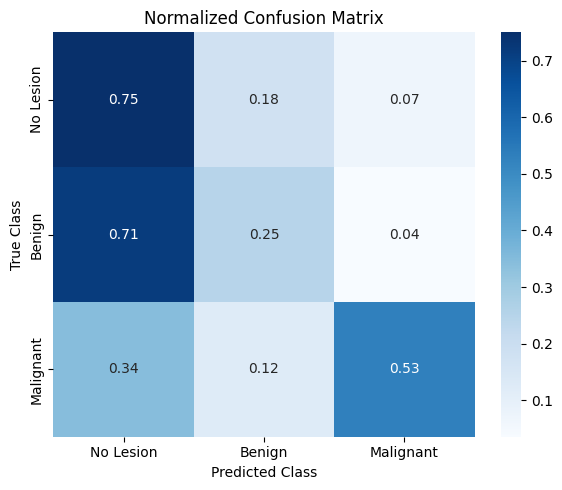

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Load results
df = pd.read_csv(file_name)

# Ground truth and predictions
y_true = df["GT"]
y_pred = df["NN"]

# Class labels
labels = [0, 1, 2]
class_names = ["No Lesion", "Benign", "Malignant"]

# Confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=labels)

# Normalized confusion matrix
cm_norm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]

# Plot
plt.figure(figsize=(6,5))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    cbar=True
)

plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.title("Normalized Confusion Matrix")

plt.tight_layout()

# Save for thesis
plt.savefig("Confusion Matrix/v3_confusion_matrix_normalized_withheading.jpg")
plt.show()

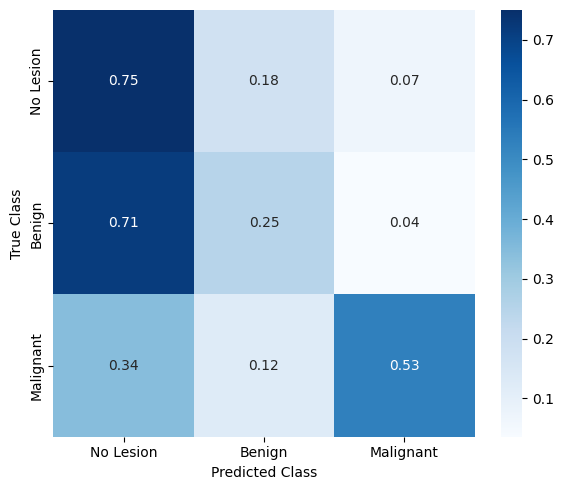

In [20]:
# Normalize confusion matrix
cm_norm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    cbar=True
)

# plt.title("Confusion Matrix (Normalized)")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")

plt.tight_layout()
plt.savefig("Confusion Matrix/v3_confusion_matrix_normalized.jpg", dpi = 150)
plt.show()

### Absolute

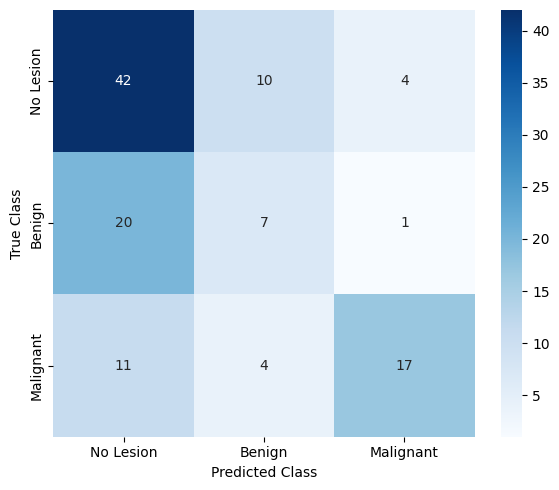

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Load results
df = pd.read_csv(file_name)

y_true = df["GT"]
y_pred = df["NN"]

labels = [0,1,2]
class_names = ["No Lesion", "Benign", "Malignant"]

cm = confusion_matrix(y_true, y_pred, labels=labels)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    cbar=True
)

# plt.title("Confusion Matrix (Counts)")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")

plt.tight_layout()
plt.savefig("Confusion Matrix/v3_confusion_matrix_counts.jpg", dpi=150)
plt.show()

### Combined

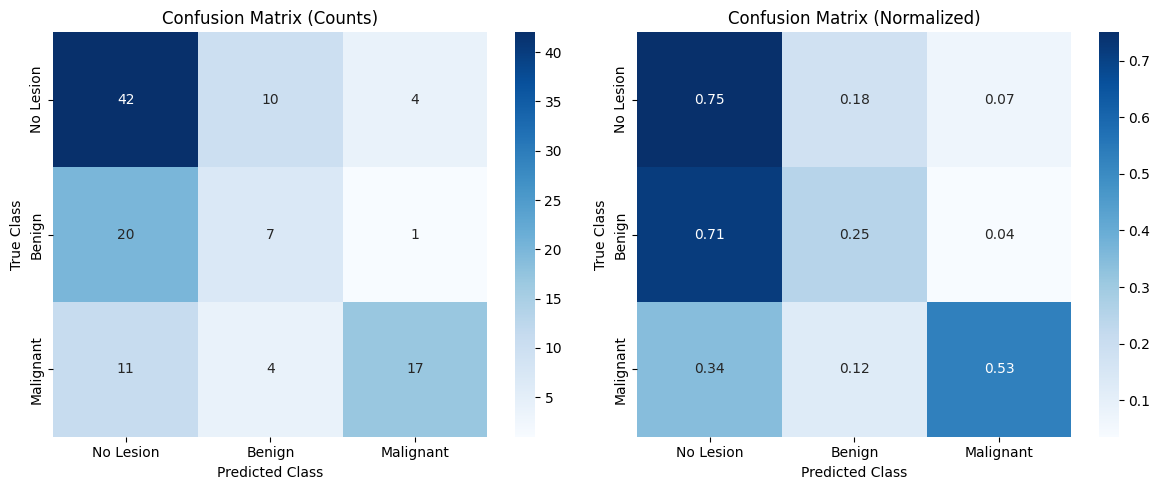

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix


# Load prediction results
df = pd.read_csv(file_name)

# Ground truth and predictions
y_true = df["GT"]
y_pred = df["NN"]

# Class labels
labels = [0,1,2]
class_names = ["No Lesion", "Benign", "Malignant"]

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=labels)

# Normalize by row (true class)
cm_norm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]

# Create figure
fig, axes = plt.subplots(1,2, figsize=(12,5))

# Absolute confusion matrix
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    cbar=True,
    ax=axes[0]
)

axes[0].set_title("Confusion Matrix (Counts)")
axes[0].set_xlabel("Predicted Class")
axes[0].set_ylabel("True Class")

# Normalized confusion matrix
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    cbar=True,
    ax=axes[1]
)

axes[1].set_title("Confusion Matrix (Normalized)")
axes[1].set_xlabel("Predicted Class")
axes[1].set_ylabel("True Class")

plt.tight_layout()

# Save figure
plt.savefig("Confusion Matrix/v3_confusion_matrix_combined.jpg",dpi=150)

plt.show()

## Create AUC-ROC

({0: np.float64(0.6913690476190476),
  1: np.float64(0.6887175324675324),
  2: np.float64(0.8139880952380952),
  'micro': np.float64(0.7801724137931034)},
 'Confusion Matrix/v3_roc_multiclass_mst.jpg')

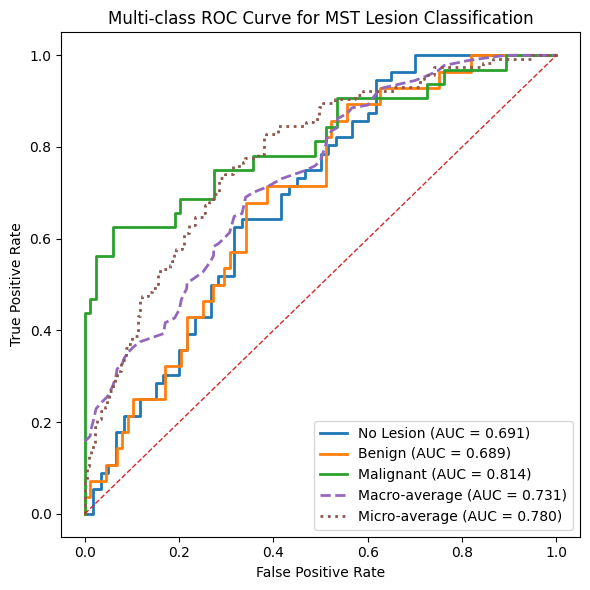

In [29]:
# Compute macro- and micro-average ROC/AUC and generate a publication-quality ROC plot

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Load data
df = pd.read_csv(file_name)

# Ground truth and probabilities
y_true = df["GT"].values
y_score = df[["prob_0","prob_1","prob_2"]].values

classes = [0,1,2]
class_names = {0:"No Lesion", 1:"Benign", 2:"Malignant"}

# Binarize labels for one-vs-rest ROC
y_true_bin = label_binarize(y_true, classes=classes)

# Compute ROC for each class
fpr = {}
tpr = {}
roc_auc = {}

for i in range(len(classes)):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Micro-average ROC
fpr["micro"], tpr["micro"], _ = roc_curve(y_true_bin.ravel(), y_score.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Macro-average ROC
# Aggregate all FPR points
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(len(classes))]))

# Interpolate TPR for each class at these points
mean_tpr = np.zeros_like(all_fpr)
for i in range(len(classes)):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])

mean_tpr /= len(classes)

fpr["macro"] = all_fpr
tpr["macro"] = mean_tpr
# roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])
macro_auc = np.mean([roc_auc[i] for i in range(len(classes))])

# --- Publication-quality plot ---
plt.figure(figsize=(6,6))

# Plot individual classes
for i in range(len(classes)):
    plt.plot(
        fpr[i], 
        tpr[i], 
        linewidth=2,
        color=f"C{i}",
        label=f'{class_names[i]} (AUC = {roc_auc[i]:.3f})'
    )

# Plot macro and micro averages
plt.plot(
    fpr["macro"], 
    tpr["macro"], 
    linestyle='--', 
    linewidth=2,
    color="C4",
    # label=f'Macro-average (AUC = {roc_auc["macro"]:.3f})'
    label=f'Macro-average (AUC = {macro_auc:.3f})'

)

plt.plot(
    fpr["micro"], 
    tpr["micro"], 
    linestyle=':', 
    linewidth=2,
    color="C5",
    label=f'Micro-average (AUC = {roc_auc["micro"]:.3f})'
)

# Chance line
plt.plot([0,1],[0,1], linestyle='--', linewidth=1, color='C3')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multi-class ROC Curve for MST Lesion Classification")
plt.legend(loc="lower right")
plt.tight_layout()

# Save figure for thesis
out_path = "Confusion Matrix/v3_roc_multiclass_mst.jpg"
plt.savefig(out_path, dpi=150)

roc_auc, out_path

### ROC only Micro and Macro Average

({0: np.float64(0.6913690476190476),
  1: np.float64(0.6887175324675324),
  2: np.float64(0.8139880952380952),
  'micro': np.float64(0.7801724137931034),
  'macro': np.float64(0.7369678126932591)},
 'Confusion Matrix/v3_roc_multiclass_mst_onlyavg.jpg')

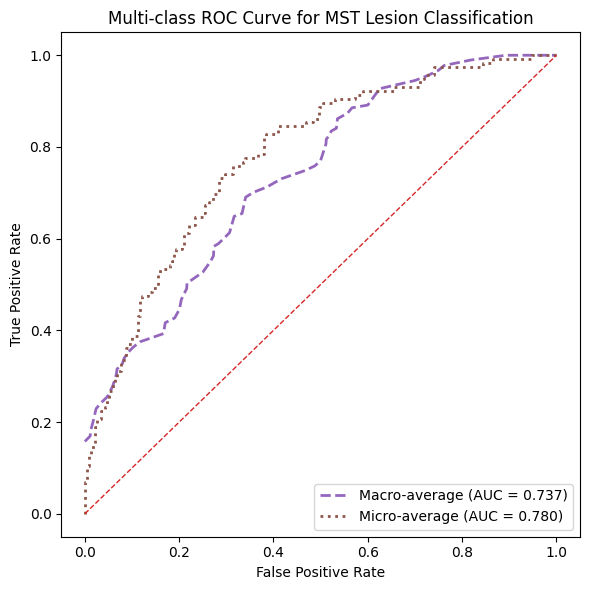

In [24]:
# --- Publication-quality plot ---
plt.figure(figsize=(6,6))

# # Plot individual classes
# for i in range(len(classes)):
#     plt.plot(
#         fpr[i], 
#         tpr[i], 
#         linewidth=2,
#         color=f"C{i}",
#         label=f'{class_names[i]} (AUC = {roc_auc[i]:.3f})'
#     )

# Plot macro and micro averages
plt.plot(
    fpr["macro"], 
    tpr["macro"], 
    linestyle='--', 
    linewidth=2,
    color="C4",
    label=f'Macro-average (AUC = {roc_auc["macro"]:.3f})'
)

plt.plot(
    fpr["micro"], 
    tpr["micro"], 
    linestyle=':', 
    linewidth=2,
    color="C5",
    label=f'Micro-average (AUC = {roc_auc["micro"]:.3f})'
)

# Chance line
plt.plot([0,1],[0,1], linestyle='--', linewidth=1, color='C3')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multi-class ROC Curve for MST Lesion Classification")
plt.legend(loc="lower right")
plt.tight_layout()

# Save figure for thesis
out_path = "Confusion Matrix/v3_roc_multiclass_mst_onlyavg.jpg"
plt.savefig(out_path, dpi=150)

roc_auc, out_path

### Only Individual Class

({0: np.float64(0.6913690476190476),
  1: np.float64(0.6887175324675324),
  2: np.float64(0.8139880952380952),
  'micro': np.float64(0.7801724137931034),
  'macro': np.float64(0.7369678126932591)},
 'Confusion Matrix/v3_roc_multiclass_mst_individual.jpg')

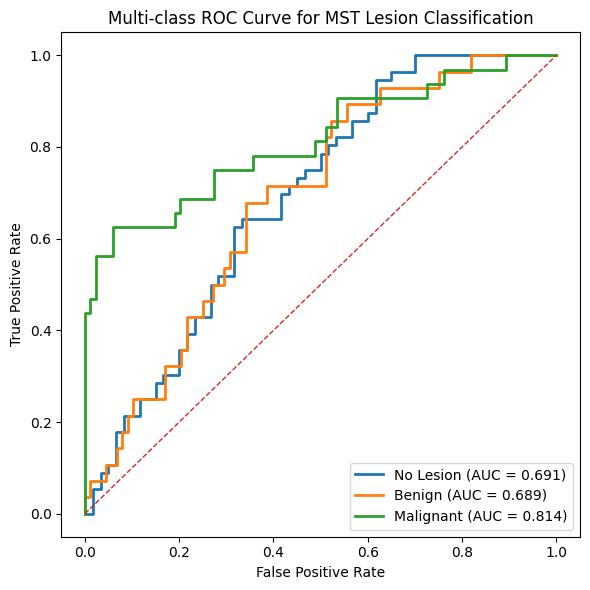

In [25]:
# --- Publication-quality plot ---
plt.figure(figsize=(6,6))

# Plot individual classes
for i in range(len(classes)):
    plt.plot(
        fpr[i], 
        tpr[i], 
        linewidth=2,
        color=f"C{i}",
        label=f'{class_names[i]} (AUC = {roc_auc[i]:.3f})'
    )

# # Plot macro and micro averages
# plt.plot(
#     fpr["macro"], 
#     tpr["macro"], 
#     linestyle='--', 
#     linewidth=2,
#     color="C4",
#     label=f'Macro-average (AUC = {roc_auc["macro"]:.3f})'
# )

# plt.plot(
#     fpr["micro"], 
#     tpr["micro"], 
#     linestyle=':', 
#     linewidth=2,
#     color="C5",
#     label=f'Micro-average (AUC = {roc_auc["micro"]:.3f})'
# )

# Chance line
plt.plot([0,1],[0,1], linestyle='--', linewidth=1, color='C3')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multi-class ROC Curve for MST Lesion Classification")
plt.legend(loc="lower right")
plt.tight_layout()

# Save figure for thesis
out_path = "Confusion Matrix/v3_roc_multiclass_mst_individual.jpg"
plt.savefig(out_path, dpi=150)

roc_auc, out_path

## LOOK list of file name

In [26]:
import pandas as pd

# Load your file
df = pd.read_csv(file_name)

# Correct predictions
correct = df[df["GT"] == df["NN"]]

# Incorrect predictions
incorrect = df[df["GT"] != df["NN"]]

# # ---- SAVE BOTH ----
# correct_grouped = correct.groupby("GT")["UID"].apply(list)
# incorrect_grouped = incorrect.groupby("GT")["UID"].apply(list)

# Group correct samples with full info
correct_grouped = correct.groupby("GT").apply(
    lambda x: x[["UID", "GT", "NN"]].to_dict(orient="records")
)

# Group incorrect samples with full info
incorrect_grouped = incorrect.groupby("GT").apply(
    lambda x: x[["UID", "GT", "NN"]].to_dict(orient="records")
)

# Save
correct_grouped.to_json("Confusion Matrix/v3_correct_full.json", indent=2)
incorrect_grouped.to_json("Confusion Matrix/v3_incorrect_full.json", indent=2)
# correct_grouped.to_json("Confusion Matrix/v3_correct_uids_per_class.json", indent=2)
# incorrect_grouped.to_json("Confusion Matrix/v3_incorrect_uids_per_class.json", indent=2)

/tmp/ipykernel_1432486/3931133022.py:17: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  correct_grouped = correct.groupby("GT").apply(
/tmp/ipykernel_1432486/3931133022.py:22: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  incorrect_grouped = incorrect.groupby("GT").apply(


In [27]:
# grouped = correct.groupby("GT")["UID"].apply(list)

# # Save to JSON or CSV
# grouped.to_json("Confusion Matrix/v3_correct_uids_per_class.json", indent=2)